## Depression Severity Classification with BiLSTM and Attention

Description: This notebook implements and trains a deep learning model for classifying depression severity based on the DAIC-WOZ dataset. The model utilizes a two-level Bidirectional LSTM (BiLSTM) with additive attention mechanism to process video-based features. It includes data loading, stratified train/validation/test splitting, custom dataset and dataloader creation with weighted sampling for class imbalance, custom loss functions (Label-smoothed Cross-Entropy and Ordinal Earth Mover's Distance), model training with early stopping, and comprehensive evaluation with various metrics and visualizations.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import joblib
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    precision_recall_fscore_support
)

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


In [ ]:
# ── Paths ────────────────────────────────────────────────────────────────────
BASE_DIR      = Path("/content/drive/MyDrive")
PROCESSED_DIR = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "data" / "processed"
WINDOWS_DIR   = PROCESSED_DIR / "windows_processed"
SAVE_DIR      = BASE_DIR / "DAIC_WOZ_VIDEO_BRANCH" / "results" / "models"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ───────────────────────────────────────────────────────────
FPS           = 30
WINDOW_SIZE   = 300      # 10 sec @ 30fps
STRIDE        = 150      # 5 sec overlap
BATCH_SIZE    = 4        # participants per batch
NUM_EPOCHS    = 100
PATIENCE      = 25
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 5        # linear warm-up before cosine decay
LABEL_SMOOTH  = 0.1      # label smoothing for CE loss
EMD_WEIGHT    = 0.2      # weight of ordinal (EMD) auxiliary loss

VAL_RATIO     = 0.15
TEST_RATIO    = 0.15
RANDOM_SEED   = 42

NUM_CLASSES   = 3
CLASS_NAMES   = ["Minimal (0-8)", "Moderate (9-16)", "Severe (17-24)"]

DROP_FEATURES = ["frame", "timestamp", "confidence", "success"]


In [ ]:
def phq_to_class(score: float) -> int:
    """PHQ-8 / PHQ-9 severity bucketing (standard clinical thresholds)."""
    if score <= 8:   return 0   # Minimal
    elif score <= 16: return 1   # Moderate
    # elif score <= 19: return 2  # Mod-Severe
    else:            return 2   # Severe


## Stratified Train / Val / Test Split
Re-derive the split from scratch so each severity class is represented proportionally
in all three subsets. This avoids the silent class imbalance that occurs when an
arbitrary pre-existing split is used.


In [ ]:
metadata_df = pd.read_csv(WINDOWS_DIR / "metadata.csv")

# Ensure severity_class column exists
metadata_df["severity_class"] = metadata_df["phq_score"].apply(phq_to_class)

# Work at participant level — one row per participant
participant_df = (
    metadata_df
    .groupby("participant_id")
    .first()
    .reset_index()[["participant_id", "phq_score", "severity_class", "window_file"]]
)

print("Total participants:", len(participant_df))
print("\nClass distribution (all):")
print(participant_df["severity_class"].value_counts().sort_index())

# ── Stratified split ──────────────────────────────────────────────────────────
# Step 1: hold out test set
trainval_df, test_df = train_test_split(
    participant_df,
    test_size=TEST_RATIO,
    stratify=participant_df["severity_class"],
    random_state=RANDOM_SEED
)

# Step 2: split remainder into train / val
val_size_adjusted = VAL_RATIO / (1 - TEST_RATIO)
train_df, val_df = train_test_split(
    trainval_df,
    test_size=val_size_adjusted,
    stratify=trainval_df["severity_class"],
    random_state=RANDOM_SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nAfter stratified split:")
print(f"  Train: {len(train_df)} participants")
print(f"  Val:   {len(val_df)} participants")
print(f"  Test:  {len(test_df)} participants")

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    counts = df["severity_class"].value_counts().sort_index()
    pcts   = (counts / len(df) * 100).round(1)
    print(f"\n{name} class distribution:")
    for cls, cnt in counts.items():
        # Temporary fix to handle cls=3 when CLASS_NAMES only has indices 0, 1, 2
        class_name_to_print = CLASS_NAMES[min(cls, len(CLASS_NAMES) - 1)]
        print(f"  Class {cls} ({class_name_to_print}): {cnt} ({pcts[cls]}%)")

Total participants: 219

Class distribution (all):
severity_class
0    144
1     54
2     21
Name: count, dtype: int64

After stratified split:
  Train: 153 participants
  Val:   33 participants
  Test:  33 participants

Train class distribution:
  Class 0 (Minimal (0-8)): 100 (65.4%)
  Class 1 (Moderate (9-16)): 38 (24.8%)
  Class 2 (Severe (17-24)): 15 (9.8%)

Val class distribution:
  Class 0 (Minimal (0-8)): 22 (66.7%)
  Class 1 (Moderate (9-16)): 8 (24.2%)
  Class 2 (Severe (17-24)): 3 (9.1%)

Test class distribution:
  Class 0 (Minimal (0-8)): 22 (66.7%)
  Class 1 (Moderate (9-16)): 8 (24.2%)
  Class 2 (Severe (17-24)): 3 (9.1%)



Fitting the scaler **after** the stratified split ensures zero leakage from
val/test statistics into the normalization parameters.


In [ ]:
scaler = StandardScaler()

for _, row in train_df.iterrows():
    # metadata row may only have one representative window_file per participant
    # Load all windows for this participant
    windows = np.load(row["window_file"])   # (W, T, F)
    frames  = windows.reshape(-1, windows.shape[-1])
    scaler.partial_fit(frames)

print(f"Scaler fitted on {len(train_df)} train participants.")
print(f"Feature dim: {scaler.n_features_in_}")

joblib.dump(scaler, PROCESSED_DIR / "scaler_stratified.pkl")
print("Scaler saved.")

del frames
gc.collect()


Scaler fitted on 153 train participants.
Feature dim: 49
Scaler saved.


11870

`WeightedRandomSampler` oversamples under-represented severity classes during
training so the model sees a roughly balanced class distribution per epoch —
complementing the weighted CE loss.


In [ ]:
class ParticipantDataset(Dataset):
    """One sample = one participant (all their windows)."""
    def __init__(self, metadata_df: pd.DataFrame, scaler: StandardScaler):
        self.metadata = metadata_df.reset_index(drop=True)
        self.scaler   = scaler

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row     = self.metadata.iloc[idx]
        raw     = np.load(row["window_file"])          # (W, T, F)
        W, T, F = raw.shape
        scaled  = (
            self.scaler
            .transform(raw.reshape(-1, F), copy=False)
            .reshape(W, T, F)
            .astype(np.float32, copy=False)
        )
        return {
            "windows":        torch.from_numpy(scaled),
            "severity_class": torch.tensor(row["severity_class"], dtype=torch.long),
            "participant_id": row["participant_id"],
        }


def participant_collate(batch):
    """Pad variable-length window sequences so they can be batched."""
    windows     = [x["windows"] for x in batch]
    num_windows = torch.tensor([w.shape[0] for w in windows])
    padded      = pad_sequence(windows, batch_first=True)  # (B, W_max, T, F)
    return {
        "windows":        padded,
        "num_windows":    num_windows,
        "severity_class": torch.stack([x["severity_class"] for x in batch]),
        "participant_id": [x["participant_id"] for x in batch],
    }


# ── Datasets ──────────────────────────────────────────────────────────────────
scaler = joblib.load(PROCESSED_DIR / "scaler_stratified.pkl")

train_dataset = ParticipantDataset(train_df, scaler)
val_dataset   = ParticipantDataset(val_df,   scaler)
test_dataset  = ParticipantDataset(test_df,  scaler)

# ── WeightedRandomSampler (over-sample rare classes in train) ─────────────────
train_labels  = train_df["severity_class"].values
class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES)
class_weights_arr = 1.0 / (class_counts + 1e-6)
sample_weights    = class_weights_arr[train_labels]
sampler = WeightedRandomSampler(
    weights     = torch.from_numpy(sample_weights).float(),
    num_samples = len(train_dataset),
    replacement = True
)

# ── DataLoaders ───────────────────────────────────────────────────────────────
train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,          # <-- replaces shuffle=True
    collate_fn  = participant_collate,
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    collate_fn = participant_collate,
)
test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle    = False,
    collate_fn = participant_collate,
)

batch = next(iter(train_loader))
print("windows shape:   ", batch["windows"].shape)      # (B, W_max, T, F)
print("num_windows:     ", batch["num_windows"])
print("severity_class:  ", batch["severity_class"])


windows shape:    torch.Size([4, 276, 300, 49])
num_windows:      tensor([272, 190, 138, 276])
severity_class:   tensor([0, 2, 2, 2])


In [ ]:
class AdditiveAttention(nn.Module):
    """
    Bahdanau-style additive attention.
    Collapses a sequence (B, L, D) → context vector (B, D).
    Supports a boolean mask (B, L) where True = PADDING (will be filled with -inf).
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1,           bias=False)

    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None):
        # x   : (B, L, D)
        # mask: (B, L) — True where positions should be ignored
        scores = self.v(torch.tanh(self.W(x))).squeeze(-1)  # (B, L)
        if mask is not None:
            scores = scores.masked_fill(mask, float("-inf"))
        weights = torch.softmax(scores, dim=-1)              # (B, L)
        # guard against all-inf rows (shouldn't happen with correct masks)
        weights = torch.nan_to_num(weights, nan=0.0)
        return (x * weights.unsqueeze(-1)).sum(dim=1)        # (B, D)


class DepressionSeverityNet(nn.Module):
    """
    Two-level BiLSTM + Attention architecture for depression severity classification.

    Level 1: per-window BiLSTM + attention  (frame compression)
    Level 2: across-window BiLSTM + attention  (session compression)
    """
    def __init__(
        self,
        input_size:  int = 49,
        win_hidden:  int = 64,    # level-1 LSTM hidden size (each direction)
        part_hidden: int = 64,    # level-2 LSTM hidden size (each direction)
        num_layers:  int = 2,     # depth for level-1 BiLSTM
        dropout:     float = 0.3,
        num_classes: int = 3,
    ):
        super().__init__()
        self.win_out_dim  = win_hidden  * 2   # 128 after BiLSTM
        self.part_out_dim = part_hidden * 2   # 128 after BiLSTM

        # ── Level 1: frame-level BiLSTM + attention ───────────────────────
        self.frame_bilstm = nn.LSTM(
            input_size    = input_size,
            hidden_size   = win_hidden,
            num_layers    = num_layers,
            batch_first   = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            bidirectional = True,
        )
        self.frame_attn = AdditiveAttention(self.win_out_dim)

        # ── Level 2: window-level BiLSTM + attention ──────────────────────
        self.window_bilstm = nn.LSTM(
            input_size    = self.win_out_dim,
            hidden_size   = part_hidden,
            num_layers    = 1,
            batch_first   = True,
            dropout       = 0.0,
            bidirectional = True,
        )
        self.window_attn = AdditiveAttention(self.part_out_dim)

        # ── Classifier head ────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(self.part_out_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    # ------------------------------------------------------------------
    def _encode_frames(self, windows_flat: torch.Tensor) -> torch.Tensor:
        """
        windows_flat : (N, T, F)  where N = B*W
        returns      : (N, win_out_dim)
        """
        lstm_out, _ = self.frame_bilstm(windows_flat)          # (N, T, D)
        return self.frame_attn(lstm_out)                        # (N, D)

    # ------------------------------------------------------------------
    def forward(
        self,
        windows:     torch.Tensor,   # (B, W_max, T, F)
        num_windows: torch.Tensor,   # (B,)
    ) -> torch.Tensor:               # (B, num_classes)

        B, W, T, F = windows.shape

        # ── Level 1: encode every window independently ────────────────
        windows_flat = windows.reshape(B * W, T, F)
        frame_embs   = self._encode_frames(windows_flat)        # (B*W, D1)
        frame_embs   = frame_embs.reshape(B, W, -1)             # (B, W, D1)

        # ── Level 2: encode window sequence ───────────────────────────
        packed = pack_padded_sequence(
            frame_embs,
            num_windows.cpu(),
            batch_first   = True,
            enforce_sorted = False,
        )
        packed_out, _ = self.window_bilstm(packed)
        win_out, _    = pad_packed_sequence(packed_out, batch_first=True)
        # win_out: (B, W_max_actual, D2)

        # Padding mask for attention: True where position >= num_windows
        max_w = win_out.size(1)
        pad_mask = (
            torch.arange(max_w, device=windows.device).unsqueeze(0)
            >= num_windows.unsqueeze(1).to(windows.device)
        )  # (B, W_max_actual)

        part_emb = self.window_attn(win_out, mask=pad_mask)     # (B, D2)

        # ── Classification head ────────────────────────────────────────
        return self.classifier(part_emb)                        # (B, num_classes)


# ── Sanity-check shape ────────────────────────────────────────────────────────
_model = DepressionSeverityNet().to(device)
_out   = _model(batch["windows"].to(device), batch["num_windows"])
print("logits shape:", _out.shape)   # expected: (B, 5)
del _model, _out


logits shape: torch.Size([4, 3])


Two complementary losses:

1. **Label-smoothed Cross-Entropy** — prevents over-confident predictions on the
   majority class, improves calibration on imbalanced data.

2. **Earth Mover's Distance (EMD) auxiliary loss** — penalises predictions that
   are far from the true class *in ordinal distance*.  A prediction of class 4
   when the true class is 0 incurs a much larger penalty than class 1 vs class 0.
   This exploits the natural ordering of PHQ severity levels.


In [ ]:
class LabelSmoothingCE(nn.Module):
    """Cross-entropy with uniform label smoothing."""
    def __init__(self, num_classes: int, smoothing: float = 0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.weight = weight            # per-class weights (tensor)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # logits : (B, C)
        # targets: (B,)
        log_probs = F.log_softmax(logits, dim=-1)          # (B, C)
        with torch.no_grad():
            smooth_labels = torch.full_like(log_probs, self.smoothing / (self.num_classes - 1))
            smooth_labels.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

        if self.weight is not None:
            w = self.weight[targets]                       # (B,)
            loss = -(smooth_labels * log_probs).sum(dim=-1) * w
            return loss.mean()

        return -(smooth_labels * log_probs).sum(dim=-1).mean()


def ordinal_emd_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """
    Earth Mover's Distance loss for ordinal classification.
    Computes the L1 distance between cumulative predicted probabilities
    and cumulative one-hot target distribution.
    Reference: Hou et al. (2017) 'Squared Earth Mover's Distance-based Loss'
    """
    num_classes = logits.size(1)
    probs       = torch.softmax(logits, dim=-1)                  # (B, C)

    # Cumulative distributions
    cum_pred   = torch.cumsum(probs, dim=-1)                     # (B, C)
    one_hot    = F.one_hot(targets, num_classes).float()         # (B, C)
    cum_target = torch.cumsum(one_hot, dim=-1)                   # (B, C)

    return torch.mean(torch.abs(cum_pred - cum_target))


# ── Class weights from training split ────────────────────────────────────────
cw = compute_class_weight(
    class_weight = "balanced",
    classes      = np.arange(NUM_CLASSES),
    y            = train_df["severity_class"].values,
)
# cw = np.sqrt(cw)
class_weight_tensor = torch.tensor(cw, dtype=torch.float32).to(device)
print("Class weights:", class_weight_tensor.cpu().numpy().round(3))

cls_criterion = LabelSmoothingCE(
    num_classes = NUM_CLASSES,
    smoothing   = LABEL_SMOOTH,
    weight      = class_weight_tensor,
    # weight      = None,
)


Class weights: [0.51  1.342 3.4  ]


In [ ]:
# EMD_WEIGHT = 0.6

In [ ]:
def get_scheduler(optimizer, warmup_epochs, total_epochs):
    """Linear warm-up then cosine annealing."""
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch + 1) / warmup_epochs
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + np.cos(np.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        windows     = batch["windows"].to(device)
        num_windows = batch["num_windows"]
        labels      = batch["severity_class"].to(device)

        optimizer.zero_grad()
        logits   = model(windows, num_windows)

        ce_loss  = cls_criterion(logits, labels)
        emd_loss = ordinal_emd_loss(logits, labels)
        loss     = ce_loss + EMD_WEIGHT * emd_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    n    = len(loader)
    f1   = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    acc  = accuracy_score(all_labels, all_preds)
    return total_loss / n, acc, f1


@torch.no_grad()
def evaluate(model, loader, device, return_arrays=False):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []

    for batch in loader:
        windows     = batch["windows"].to(device)
        num_windows = batch["num_windows"]
        labels      = batch["severity_class"].to(device)

        logits   = model(windows, num_windows)
        ce_loss  = cls_criterion(logits, labels)
        emd_loss = ordinal_emd_loss(logits, labels)
        total_loss += (ce_loss + EMD_WEIGHT * emd_loss).item()

        preds = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    metrics = {
        "loss":      total_loss / len(loader),
        "acc":       accuracy_score(all_labels, all_preds),
        "macro_f1":  f1_score(all_labels, all_preds, average="macro",    zero_division=0),
        "w_f1":      f1_score(all_labels, all_preds, average="weighted", zero_division=0),
        "per_class_f1": f1_score(all_labels, all_preds,
                                  average=None, labels=list(range(NUM_CLASSES)),
                                  zero_division=0),
    }
    if return_arrays:
        metrics["preds"]  = np.array(all_preds)
        metrics["labels"] = np.array(all_labels)
    return metrics


In [ ]:
model     = DepressionSeverityNet(
    input_size  = 49,
    win_hidden  = 64,
    part_hidden = 64,
    num_layers  = 2,
    dropout     = 0.3,
    num_classes = NUM_CLASSES,
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = get_scheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")
print(f"Device: {device}  |  Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

best_val_f1      = 0.0
patience_counter = 0
history          = []
BEST_MODEL_PATH  = SAVE_DIR / "best_bilstm_attn_cls.pt"

print("\n" + "=" * 80)
print(f"{'Ep':>4} | {'TrLoss':>8} {'TrF1':>7} | {'VlLoss':>8} {'VlAcc':>7} {'VlMF1':>7} | {'LR':>9} | Note")
print("=" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = train_one_epoch(model, train_loader, optimizer, device)
    val_m = evaluate(model, val_loader, device)
    scheduler.step()

    cur_lr = optimizer.param_groups[0]["lr"]
    note   = ""

    history.append({
        "epoch":    epoch,
        "tr_loss":  tr_loss,
        "tr_f1":    tr_f1,
        "val_loss": val_m["loss"],
        "val_acc":  val_m["acc"],
        "val_f1":   val_m["macro_f1"],
        "val_wf1":  val_m["w_f1"],
        "lr":       cur_lr,
    })

    if val_m["macro_f1"] > best_val_f1:
        best_val_f1 = val_m["macro_f1"]
        patience_counter = 0
        torch.save({
            "epoch":            epoch,
            "model_state_dict": model.state_dict(),
            "model_config": {
                "input_size":  49, "win_hidden": 64, "part_hidden": 64,
                "num_layers":  2,  "dropout":    0.3, "num_classes": NUM_CLASSES,
            },
            "scaler_mean":  torch.tensor(scaler.mean_,  dtype=torch.float32),
            "scaler_scale": torch.tensor(scaler.scale_, dtype=torch.float32),
            "best_val_f1":  best_val_f1,
            "label_map":    {i: n for i, n in enumerate(CLASS_NAMES)},
        }, BEST_MODEL_PATH)
        note = f"✓ best F1={best_val_f1:.4f}"
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}.")
            break

    print(
        f"{epoch:4d} | {tr_loss:8.4f} {tr_f1:7.4f} | "
        f"{val_m['loss']:8.4f} {val_m['acc']:7.4f} {val_m['macro_f1']:7.4f} | "
        f"{cur_lr:9.2e} | {note}"
    )

print(f"\nBest Val Macro-F1: {best_val_f1:.4f}")


Trainable parameters: 307,715
Device: cuda  |  Train: 153  |  Val: 33

  Ep |   TrLoss    TrF1 |   VlLoss   VlAcc   VlMF1 |        LR | Note
   1 |   1.8156  0.2587 |   1.2144  0.0909  0.0606 |  4.00e-05 | ✓ best F1=0.0606
   2 |   1.8454  0.2419 |   1.2648  0.0909  0.0556 |  6.00e-05 | 
   3 |   1.7403  0.2011 |   1.3125  0.0909  0.0571 |  8.00e-05 | 
   4 |   1.6239  0.2302 |   1.2467  0.0909  0.0571 |  1.00e-04 | 
   5 |   1.5093  0.2655 |   1.1574  0.2121  0.2019 |  1.00e-04 | ✓ best F1=0.2019
   6 |   1.4559  0.3464 |   1.1084  0.2424  0.2316 |  1.00e-04 | ✓ best F1=0.2316
   7 |   1.4306  0.4508 |   1.1727  0.2424  0.2286 |  9.99e-05 | 
   8 |   1.3407  0.4140 |   1.0829  0.2727  0.2815 |  9.98e-05 | ✓ best F1=0.2815
   9 |   1.2468  0.4719 |   1.1803  0.2424  0.2361 |  9.96e-05 | 
  10 |   1.2666  0.4972 |   1.1831  0.2121  0.2254 |  9.93e-05 | 
  11 |   1.2896  0.5302 |   1.2103  0.2727  0.3166 |  9.90e-05 | ✓ best F1=0.3166
  12 |   1.1920  0.5701 |   1.1679  0.2727  0.3121 | 

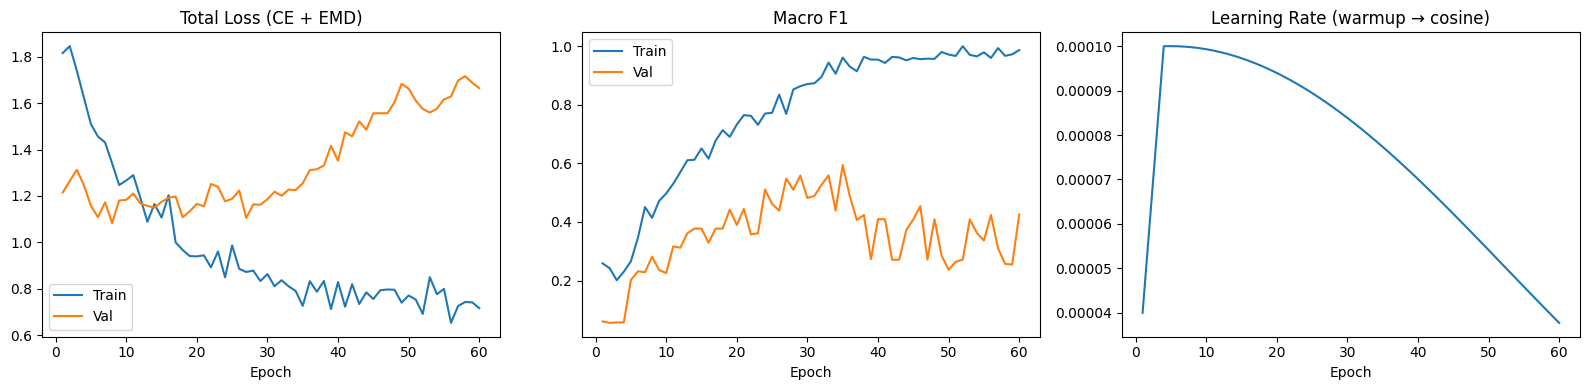

In [ ]:
hist = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(hist["epoch"], hist["tr_loss"],  label="Train")
axes[0].plot(hist["epoch"], hist["val_loss"], label="Val")
axes[0].set_title("Total Loss (CE + EMD)"); axes[0].legend()
axes[0].set_xlabel("Epoch")

axes[1].plot(hist["epoch"], hist["tr_f1"],  label="Train")
axes[1].plot(hist["epoch"], hist["val_f1"], label="Val")
axes[1].set_title("Macro F1"); axes[1].legend()
axes[1].set_xlabel("Epoch")

axes[2].plot(hist["epoch"], hist["lr"])
axes[2].set_title("Learning Rate (warmup → cosine)")
axes[2].set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves.png", dpi=130)
plt.show()


## Final Test Evaluation
Load the best checkpoint and evaluate on the held-out stratified test set.


In [ ]:
# # Load best model
# bundle = torch.load(BEST_MODEL_PATH, map_location=device, weights_only=False)
# model  = DepressionSeverityNet(**bundle["model_config"]).to(device)
# model.load_state_dict(bundle["model_state_dict"])
# print(f"Loaded checkpoint from epoch {bundle['epoch']}  |  "
#       f"Best val macro-F1: {bundle['best_val_f1']:.4f}")

Loaded checkpoint from epoch 35  |  Best val macro-F1: 0.3773


In [ ]:
# Evaluate
test_m = evaluate(model, test_loader, device, return_arrays=True)

print("\n" + "=" * 55)
print("TEST RESULTS  (participant-level, stratified split)")
print("=" * 55)
print(f"  Accuracy:        {test_m['acc']:.4f}")
print(f"  Macro F1:        {test_m['macro_f1']:.4f}")
print(f"  Weighted F1:     {test_m['w_f1']:.4f}")
print("\nPer-class F1:")
for i, (name, f1) in enumerate(zip(CLASS_NAMES, test_m["per_class_f1"])):
    print(f"  [{i}] {name:<22}: {f1:.4f}")



TEST RESULTS  (participant-level, stratified split)
  Accuracy:        0.5455
  Macro F1:        0.4306
  Weighted F1:     0.5581

Per-class F1:
  [0] Minimal (0-8)         : 0.6667
  [1] Moderate (9-16)       : 0.3750
  [2] Severe (17-24)        : 0.2500


# 0.75

In [ ]:
print("\nDetailed Classification Report:")
print(classification_report(
    test_m["labels"],
    test_m["preds"],
    target_names=CLASS_NAMES,
    digits=4,
    zero_division=0
))



Detailed Classification Report:
                 precision    recall  f1-score   support

  Minimal (0-8)     0.7000    0.6364    0.6667        22
Moderate (9-16)     0.3750    0.3750    0.3750         8
 Severe (17-24)     0.2000    0.3333    0.2500         3

       accuracy                         0.5455        33
      macro avg     0.4250    0.4482    0.4306        33
   weighted avg     0.5758    0.5455    0.5581        33



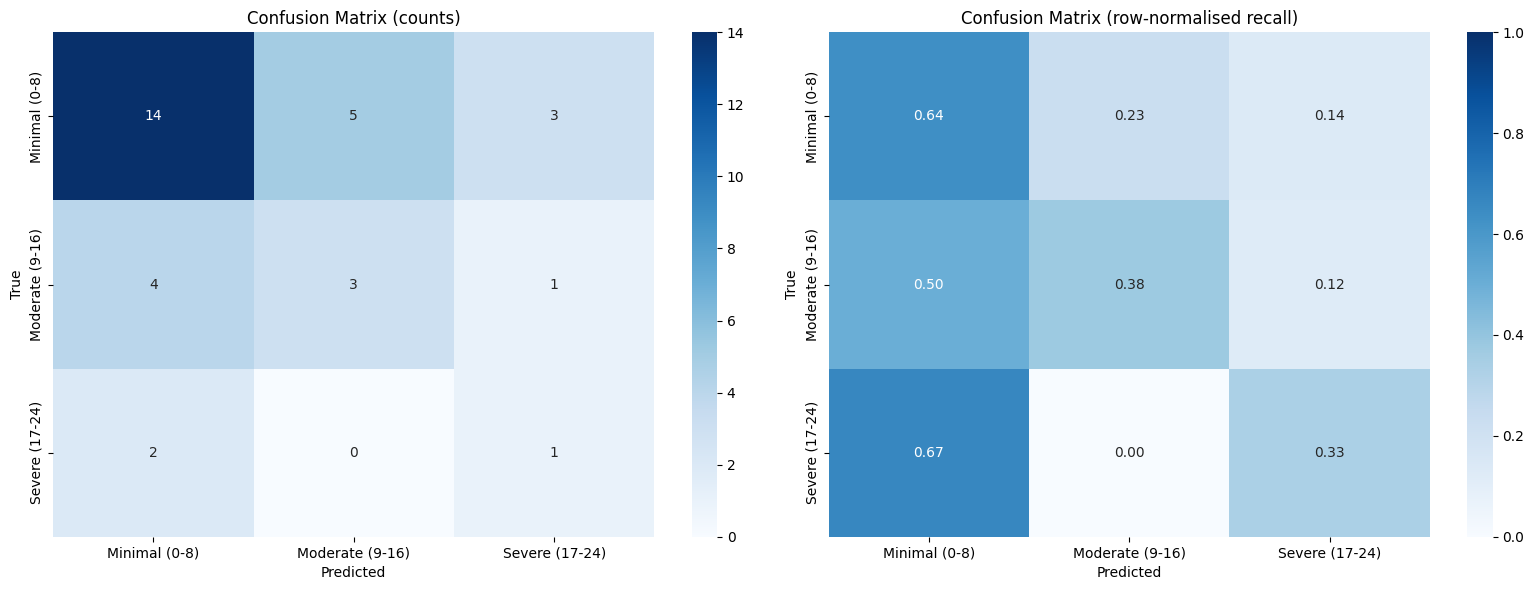

In [ ]:
cm = confusion_matrix(test_m["labels"], test_m["preds"], labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Raw counts ────────────────────────────────────────────────────────────────
sns.heatmap(
    cm,
    annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[0]
)
axes[0].set_title("Confusion Matrix (counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

# ── Row-normalised (recall per class) ────────────────────────────────────────
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    ax=axes[1]
)
axes[1].set_title("Confusion Matrix (row-normalised recall)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=130)
plt.show()


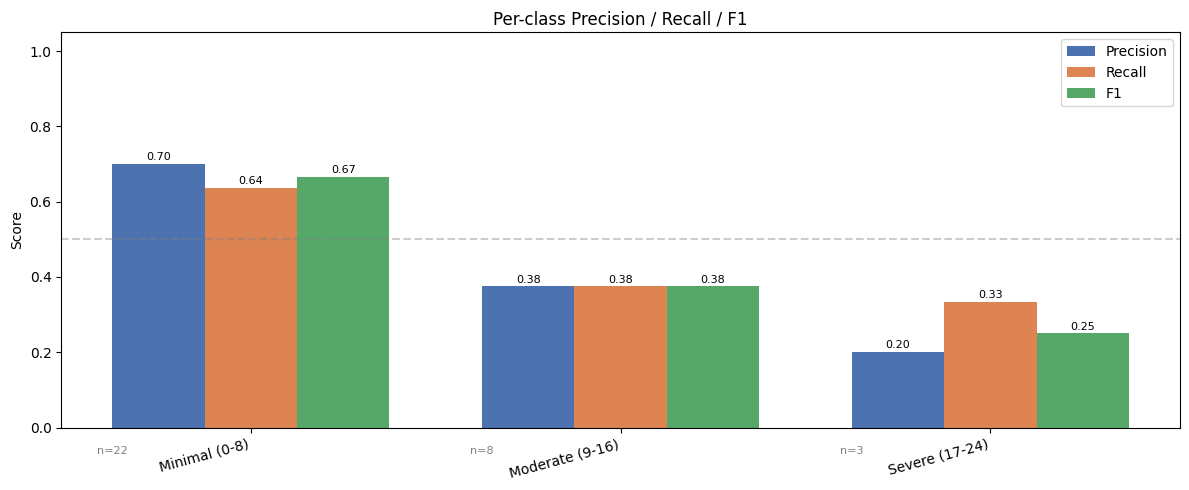

In [ ]:
precision, recall, f1, support = precision_recall_fscore_support(
    test_m["labels"],
    test_m["preds"],
    labels=list(range(NUM_CLASSES)),
    zero_division=0
)

x    = np.arange(NUM_CLASSES)
w    = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, precision, w, label="Precision", color="#4C72B0")
ax.bar(x,     recall,    w, label="Recall",    color="#DD8452")
ax.bar(x + w, f1,        w, label="F1",        color="#55A868")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=15, ha="right")
ax.set_ylabel("Score"); ax.set_title("Per-class Precision / Recall / F1")
ax.set_ylim(0, 1.05); ax.legend()
ax.axhline(0.5, linestyle="--", color="grey", alpha=0.4)

for i, (p, r, f, s) in enumerate(zip(precision, recall, f1, support)):
    ax.text(i - w,   p + 0.01, f"{p:.2f}", ha="center", fontsize=8)
    ax.text(i,       r + 0.01, f"{r:.2f}", ha="center", fontsize=8)
    ax.text(i + w,   f + 0.01, f"{f:.2f}", ha="center", fontsize=8)
    ax.text(i - w*1.5, -0.07,  f"n={s}",  ha="center", fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("per_class_metrics.png", dpi=130)
plt.show()


In [ ]:
# Mean absolute class-distance (ordinal error)
ord_error = np.abs(test_m["labels"] - test_m["preds"])
print("Ordinal Error Distribution:")
for dist, cnt in sorted(Counter(ord_error).items()):
    print(f"  |true - pred| = {dist}:  {cnt} participants  ({cnt/len(ord_error)*100:.1f}%)")
print(f"\nMean ordinal error: {ord_error.mean():.3f} severity classes")
print(f"Exact match (0-distance): {(ord_error == 0).sum()} / {len(ord_error)} "
      f"({(ord_error == 0).mean()*100:.1f}%)")
print(f"Within-1-class accuracy:  {(ord_error <= 1).sum()} / {len(ord_error)} "
      f"({(ord_error <= 1).mean()*100:.1f}%)")


In [ ]:
# # The best checkpoint was already saved during training.
# # Save training history separately for later analysis.
# hist.to_csv(SAVE_DIR / "training_history.csv", index=False)
# print(f"Training history saved → {SAVE_DIR / 'training_history.csv'}")
# print(f"Best model checkpoint  → {BEST_MODEL_PATH}")
